In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [17]:
df=pd.read_csv('C:\\Users\\Sowndarya\\OneDrive\\Desktop\\DataAnalytics\\AI&ML\\Project-ML\\Regression_dataset\\carprice.csv')

In [18]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
195,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
197,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          199 non-null    int64  
 1   normalized-losses  199 non-null    object 
 2   make               199 non-null    object 
 3   fuel-type          199 non-null    object 
 4   aspiration         199 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         199 non-null    object 
 7   drive-wheels       199 non-null    object 
 8   engine-location    199 non-null    object 
 9   wheel-base         199 non-null    float64
 10  length             199 non-null    float64
 11  width              199 non-null    float64
 12  height             199 non-null    float64
 13  curb-weight        199 non-null    int64  
 14  engine-type        199 non-null    object 
 15  num-of-cylinders   199 non-null    object 
 16  engine-size        199 non

In [20]:
df['normalized-losses']=df['normalized-losses'].replace('?',np.nan)
df['num-of-doors']=df['num-of-doors'].replace('?',np.nan)
df['price']=df['price'].replace('?',np.nan)

In [21]:
df.isnull().sum()

symboling             0
normalized-losses    39
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  0
stroke                0
compression-ratio     0
horsepower            0
peak-rpm              0
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [22]:
df['normalized-losses'].fillna(df['normalized-losses'].mode()[0],inplace=True)
df['num-of-doors'].fillna(df['num-of-doors'].mode()[0],inplace=True)
df['price'].fillna(df['price'].mode()[0],inplace=True)


C:\Users\Sowndarya\AppData\Local\Temp\ipykernel_4000\3525438300.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['normalized-losses'].fillna(df['normalized-losses'].mode()[0],inplace=True)
C:\Users\Sowndarya\AppData\Local\Temp\ipykernel_4000\3525438300.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [23]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [24]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,0.788945,98.852764,174.099497,65.905528,53.816583,2558.829146,127.949749,3.328442,3.248945,10.171960,104.150754,5107.788945,25.412060,30.904523
std,1.220895,6.085940,12.489391,2.176300,2.395002,528.005482,41.534670,0.274602,0.311583,4.027676,40.051827,467.587982,6.523544,6.900880
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.000000,52.000000,2142.500000,98.000000,3.150000,3.110000,8.500000,70.000000,4800.000000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.400000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,25.000000,30.000000
75%,2.000000,102.400000,183.500000,66.900000,55.550000,2953.000000,145.500000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,36.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000


In [25]:
df.dtypes

symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

In [28]:
catgrcl_column=['normalized-losses','make','fuel-type','aspiration','num-of-doors','body-style','drive-wheels','engine-location','engine-type','num-of-cylinders','fuel-system','price']
le=LabelEncoder()
for col in catgrcl_column:
    df[col]=le.fit_transform(df[col])

In [29]:
df.dtypes

symboling              int64
normalized-losses      int64
make                   int64
fuel-type              int64
aspiration             int64
num-of-doors           int64
body-style             int64
drive-wheels           int64
engine-location        int64
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type            int64
num-of-cylinders       int64
engine-size            int64
fuel-system            int64
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

In [41]:
s=StandardScaler()

In [43]:
df['price']=s.fit_transform(df[['price']])

In [44]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,26,0,1,0,1,0,2,0,88.6,...,130,4,3.47,2.68,9.0,111,5000,21,27,-1.182203
1,3,26,0,1,0,1,0,2,0,88.6,...,130,4,3.47,2.68,9.0,111,5000,21,27,-0.856121
2,1,26,0,1,0,1,2,2,0,94.5,...,152,4,2.68,3.47,9.0,154,5000,19,26,-0.856121
3,2,27,1,1,0,0,3,1,0,99.8,...,109,4,3.19,3.40,10.0,102,5500,24,30,-1.105478
4,2,27,1,1,0,0,3,0,0,99.4,...,136,4,3.19,3.40,8.0,115,5500,18,22,-0.645127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,-1,49,20,1,0,0,3,2,0,109.1,...,141,4,3.78,3.15,9.5,114,5400,23,28,-0.741034
195,-1,49,20,1,1,0,3,2,0,109.1,...,141,4,3.78,3.15,8.7,160,5300,19,25,-0.414952
196,-1,49,20,1,0,0,3,2,0,109.1,...,173,4,3.58,2.87,8.8,134,5500,18,23,-0.338227
197,-1,49,20,0,1,0,3,2,0,109.1,...,145,2,3.01,3.40,23.0,106,4800,26,27,-0.299864


In [45]:
x=df.drop(columns='price',axis=1)
y=df['price']

In [46]:
print(x)

     symboling  normalized-losses  make  fuel-type  aspiration  num-of-doors  \
0            3                 26     0          1           0             1   
1            3                 26     0          1           0             1   
2            1                 26     0          1           0             1   
3            2                 27     1          1           0             0   
4            2                 27     1          1           0             0   
..         ...                ...   ...        ...         ...           ...   
194         -1                 49    20          1           0             0   
195         -1                 49    20          1           1             0   
196         -1                 49    20          1           0             0   
197         -1                 49    20          0           1             0   
198         -1                 49    20          1           1             0   

     body-style  drive-wheels  engine-l

In [47]:
print(y)

0     -1.182203
1     -0.856121
2     -0.856121
3     -1.105478
4     -0.645127
         ...   
194   -0.741034
195   -0.414952
196   -0.338227
197   -0.299864
198   -0.280683
Name: price, Length: 199, dtype: float64


In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [49]:
model=LinearRegression()

In [50]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
x_tst_prediction=model.predict(x_test)
print(x_tst_prediction)

[ 0.64982316 -0.41208431 -0.77216387  0.24566585 -0.18130115 -0.10248397
 -0.363015   -0.45239218  0.04180236  0.04655611 -0.05598287  0.75985612
 -1.05085849  0.56640078 -0.09798394  0.6145598  -0.14262965  0.13563729
  0.53182159  0.09010564 -1.12868781 -0.2456779   0.64748567  0.04017813
 -1.21415453 -0.63859942  0.88329092 -1.40145314  0.21903731 -0.02700127
 -0.78536731  0.49567622 -0.51885066 -0.35220746 -0.15739194  0.38902754
 -0.83459134 -0.10805133  0.18534527 -0.32351425]


In [52]:
mse=mean_squared_error(y_test,x_tst_prediction)
r2=r2_score(y_test,x_tst_prediction)

In [53]:
print('mse:',mse)
print('r2_score:',r2)

mse: 0.7989268145467161
r2_score: 0.1528613620725905


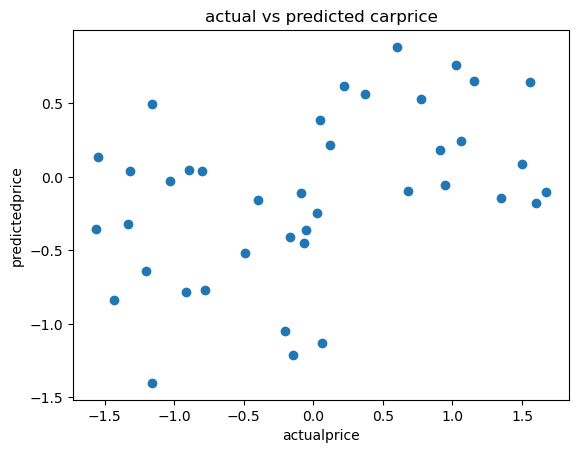

In [54]:
plt.figure()
plt.scatter(y_test,x_tst_prediction)
plt.xlabel('actualprice')
plt.ylabel('predictedprice')
plt.title('actual vs predicted carprice')
plt.show()

In [61]:
newdata=[[3,105,20,0,1,0,3,0,0,93.1,160,65.8,71.4,50,2191,1,209,4,3.54,3.40,23,115,6600,49,54]]

In [63]:
newdata_s=s.fit_transform(newdata)

In [64]:
print(newdata_s)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]]


In [65]:
output_prdctn=model.predict(newdata_s)
print(output_prdctn)

[10.9830845]


C:\Users\Sowndarya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [68]:
print('predicted_sale:',output_prdctn[0]*1000)

predicted_sale: 10983.084498119018
